In [63]:
import json

In [79]:
pi = dict()

for uc in [1, 2, 5, 10, 20, 30, 40, 50]:
    with open(f"data/uc-{uc}/seed-1/epoch_19.json") as f:
        pi[uc] = json.load(f)['pi']

In [65]:
import pandas as pd

In [66]:
pi = pd.DataFrame(pi)

In [67]:
pi

,0
0,0.000025
1,0.000025
2,0.000025
3,0.000025
4,0.000025
...,...
23995,0.000125
23996,0.000125
23997,0.000125
23998,0.000125


In [68]:
pi = pi.sort_values(by=0, ascending=False).reset_index(drop=True)

In [69]:
pi[0][0]

np.float64(0.00012513888941612095)

In [70]:
pi[0][len(pi) - 1]

np.float64(2.499490619811695e-05)

In [71]:
#t = 2.8e-05  # пример порога

t=0.001

sum_gt = pi[pi[0] > t][0].sum()
sum_lt = pi[pi[0] < t][0].sum()

print("sum > t:", sum_gt)
print("sum < t:", sum_lt)

sum > t: 0.0
sum < t: 0.9999999908741302


In [72]:
len(pi)

24000

In [73]:
threshold = 0.5  # пример

# сортировка по убыванию
pi_sorted = pi[0].sort_values(ascending=False).reset_index(drop=True)

# кумулятивная сумма
cumsum = pi_sorted.cumsum()

# индекс k
k = (cumsum < threshold).sum() + 1
print("k =", k)

k = 4000


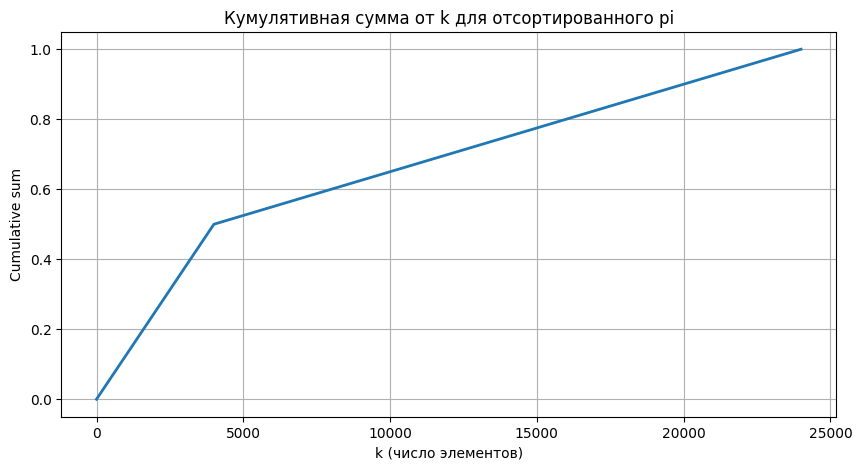

In [74]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(cumsum, linewidth=2)
plt.xlabel("k (число элементов)")
plt.ylabel("Cumulative sum")
plt.title("Кумулятивная сумма от k для отсортированного pi")
plt.grid(True)
plt.show()